<a href="https://colab.research.google.com/github/faiza-alee/AI-fundamentals/blob/main/email_spam_classification_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# STEP 1: Install Kaggle API
!pip install -q kaggle

# STEP 2: Upload kaggle.json (API key) from your computer
from google.colab import files
files.upload()   # <-- Choose kaggle.json file

# STEP 3: Move kaggle.json to the correct folder
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# STEP 4: Download dataset from Kaggle (example: SMS Spam Collection)
# !kaggle datasets download -d uciml/sms-spam-collection-dataset
!kaggle datasets download -d balaka18/email-spam-classification-dataset-csv

# STEP 5: Unzip dataset
# !unzip sms-spam-collection-dataset.zip
!unzip -o email-spam-classification-dataset-csv.zip -d spam_dataset


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/balaka18/email-spam-classification-dataset-csv
License(s): ODbL-1.0
  0% 0.00/1.66M [00:00<?, ?B/s]
100% 1.66M/1.66M [00:00<00:00, 965MB/s]
Archive:  email-spam-classification-dataset-csv.zip
  inflating: spam_dataset/emails.csv  


In [21]:
import pandas as pd

# Load dataset (adjust filename if needed)
df = pd.read_csv("spam_dataset/emails.csv")

# 'Prediction' is the label column, and the rest (excluding 'Email No.') are features (word counts)
# Drop the 'Email No.' column as it's just an identifier
df = df.drop('Email No.', axis=1)

# Rename 'Prediction' to 'label' for clarity
df.rename(columns={'Prediction': 'label'}, inplace=True)

print(df.head())

   the  to  ect  and  for  of    a  you  hou  in  ...  connevey  jay  valued  \
0    0   0    1    0    0   0    2    0    0   0  ...         0    0       0   
1    8  13   24    6    6   2  102    1   27  18  ...         0    0       0   
2    0   0    1    0    0   0    8    0    0   4  ...         0    0       0   
3    0   5   22    0    5   1   51    2   10   1  ...         0    0       0   
4    7   6   17    1    5   2   57    0    9   3  ...         0    0       0   

   lay  infrastructure  military  allowing  ff  dry  label  
0    0               0         0         0   0    0      0  
1    0               0         0         0   1    0      0  
2    0               0         0         0   0    0      0  
3    0               0         0         0   0    0      0  
4    0               0         0         0   1    0      0  

[5 rows x 3001 columns]


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Download NLTK data
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [6]:
# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (5172, 3002)

First 5 rows:
  Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  jay  \
0   Email 1    0   0    1    0    0   0    2    0    0  ...         0    0   
1   Email 2    8  13   24    6    6   2  102    1   27  ...         0    0   
2   Email 3    0   0    1    0    0   0    8    0    0  ...         0    0   
3   Email 4    0   5   22    0    5   1   51    2   10  ...         0    0   
4   Email 5    7   6   17    1    5   2   57    0    9  ...         0    0   

   valued  lay  infrastructure  military  allowing  ff  dry  Prediction  
0       0    0               0         0         0   0    0           0  
1       0    0               0         0         0   1    0           0  
2       0    0               0         0         0   0    0           0  
3       0    0               0         0         0   0    0           0  
4       0    0               0         0         0   1    0           0  

[5 rows x 3002 columns]


In [7]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Columns: 3002 entries, Email No. to Prediction
dtypes: int64(3001), object(1)
memory usage: 118.5+ MB
None


In [8]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here', 'like', 'b', 'flow', '

In [9]:
df = df.iloc[:, :2]
df.columns = ['label', 'message']


In [10]:
print("\nCleaned dataset:")
print(df.head())



Cleaned dataset:
     label  message
0  Email 1        0
1  Email 2        8
2  Email 3        0
3  Email 4        0
4  Email 5        7


In [11]:
print("\nClass distribution:")
print(df['label'].value_counts())


Class distribution:
label
Email 5172    1
Email 1       1
Email 2       1
Email 3       1
Email 5156    1
             ..
Email 9       1
Email 8       1
Email 7       1
Email 6       1
Email 5       1
Name: count, Length: 5172, dtype: int64


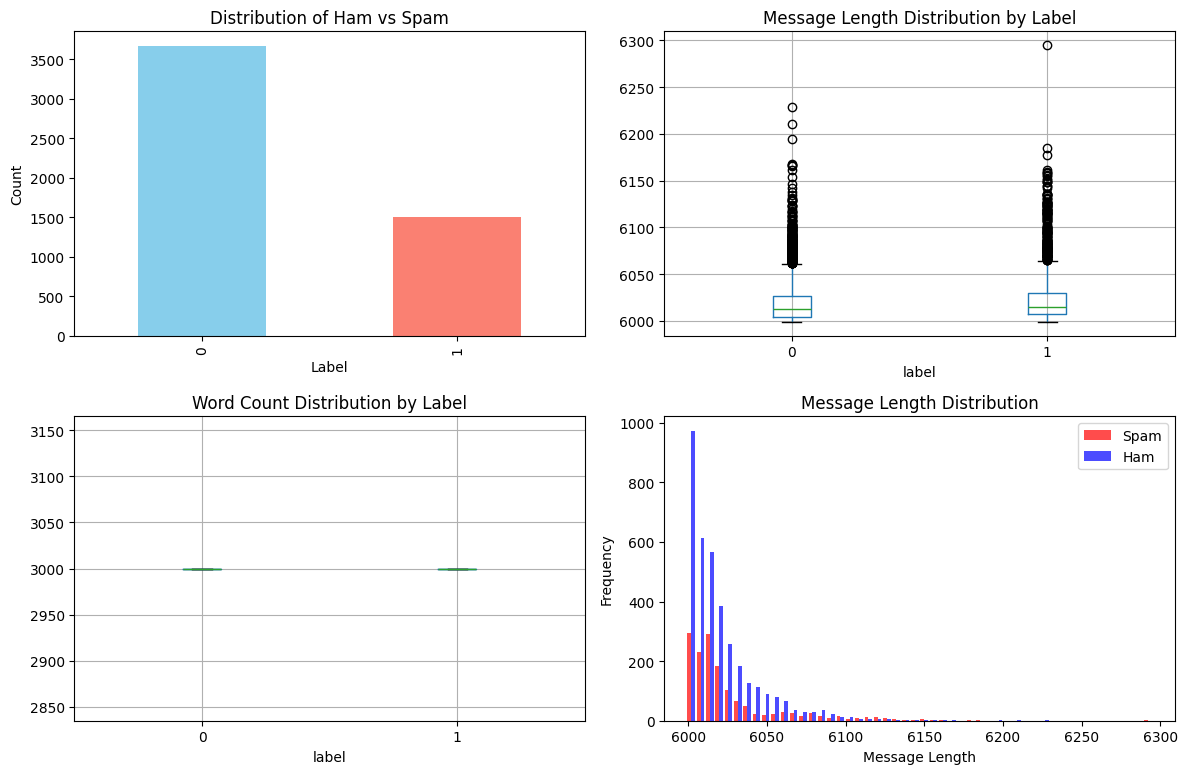

In [15]:
# Visualize class distribution
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
# Assuming 'label' is the correct column for the target variable (spam/ham)
df['label'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Ham vs Spam')
plt.xlabel('Label')
plt.ylabel('Count')

# Message length analysis
# Concatenate all word columns to form the email message string
df['message'] = df.iloc[:, 2:].astype(str).agg(' '.join, axis=1)
df['message_length'] = df['message'].str.len()

plt.subplot(2, 2, 2)
# Ensure 'label' column is used for grouping
df.boxplot(column='message_length', by='label', ax=plt.gca())
plt.title('Message Length Distribution by Label')
plt.suptitle('')

# Word count analysis
df['word_count'] = df['message'].str.split().str.len()

plt.subplot(2, 2, 3)
# Ensure 'label' column is used for grouping
df.boxplot(column='word_count', by='label', ax=plt.gca())
plt.title('Word Count Distribution by Label')
plt.suptitle('')

plt.subplot(2, 2, 4)
# Filter based on the correct 'label' column
spam_messages = df[df['label'] == 1]['message'] # Assuming 1 is spam
ham_messages = df[df['label'] == 0]['message'] # Assuming 0 is ham


plt.hist([spam_messages.str.len(), ham_messages.str.len()],
         bins=50, alpha=0.7, label=['Spam', 'Ham'], color=['red', 'blue'])
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.title('Message Length Distribution')
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
# Step 5: Text Preprocessing (Not applicable in this case as data is already in Bag-of-Words format)
# The features are already numerical word counts.

print("Text preprocessing is not required as the dataset is in Bag-of-Words format.")

Text preprocessing is not required as the dataset is in Bag-of-Words format.


In [22]:
# Step 6: Feature Engineering (Not needed in the traditional sense as features are already numerical)

# Separate features (X) and target (y)
X = df.drop('label', axis=1)
y = df['label']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (5172, 3000)
Target vector shape: (5172,)


In [20]:
# Inspect the cleaned_message column
print("\nInspecting cleaned_message column:")
print(df['cleaned_message'].head())
print("\nChecking for empty strings in cleaned_message:")
print((df['cleaned_message'] == "").sum())


Inspecting cleaned_message column:
0    
1    
2    
3    
4    
Name: cleaned_message, dtype: object

Checking for empty strings in cleaned_message:
5172


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 4137
Test set size: 1035


In [27]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

In [29]:
# Step 9: Train and Evaluate Models
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train and evaluate a model"""
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Predictions': y_pred
    }

# Evaluate models
print("Evaluating models...")
results = []

for name, model in models.items():
    print(f"Training {name}...")
    result = evaluate_model(model, X_train, X_test, y_train, y_test, name)
    results.append(result)

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(results_df.to_string(index=False))

Evaluating models...
Training Logistic Regression...
Training Naive Bayes...
Training Random Forest...
Training Decision Tree...
Training K-Nearest Neighbors...

MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score                                                                                                                                                                                                                                                                                                       Predictions
Logistic Regression    0.9826     0.9578  0.9833    0.9704 [0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...]
        Naive Bayes    0.9420     0.8681  0.9433    0.9042 [0, 0, 0, 0, 1, 1, 0

<Figure size 1500x1000 with 0 Axes>

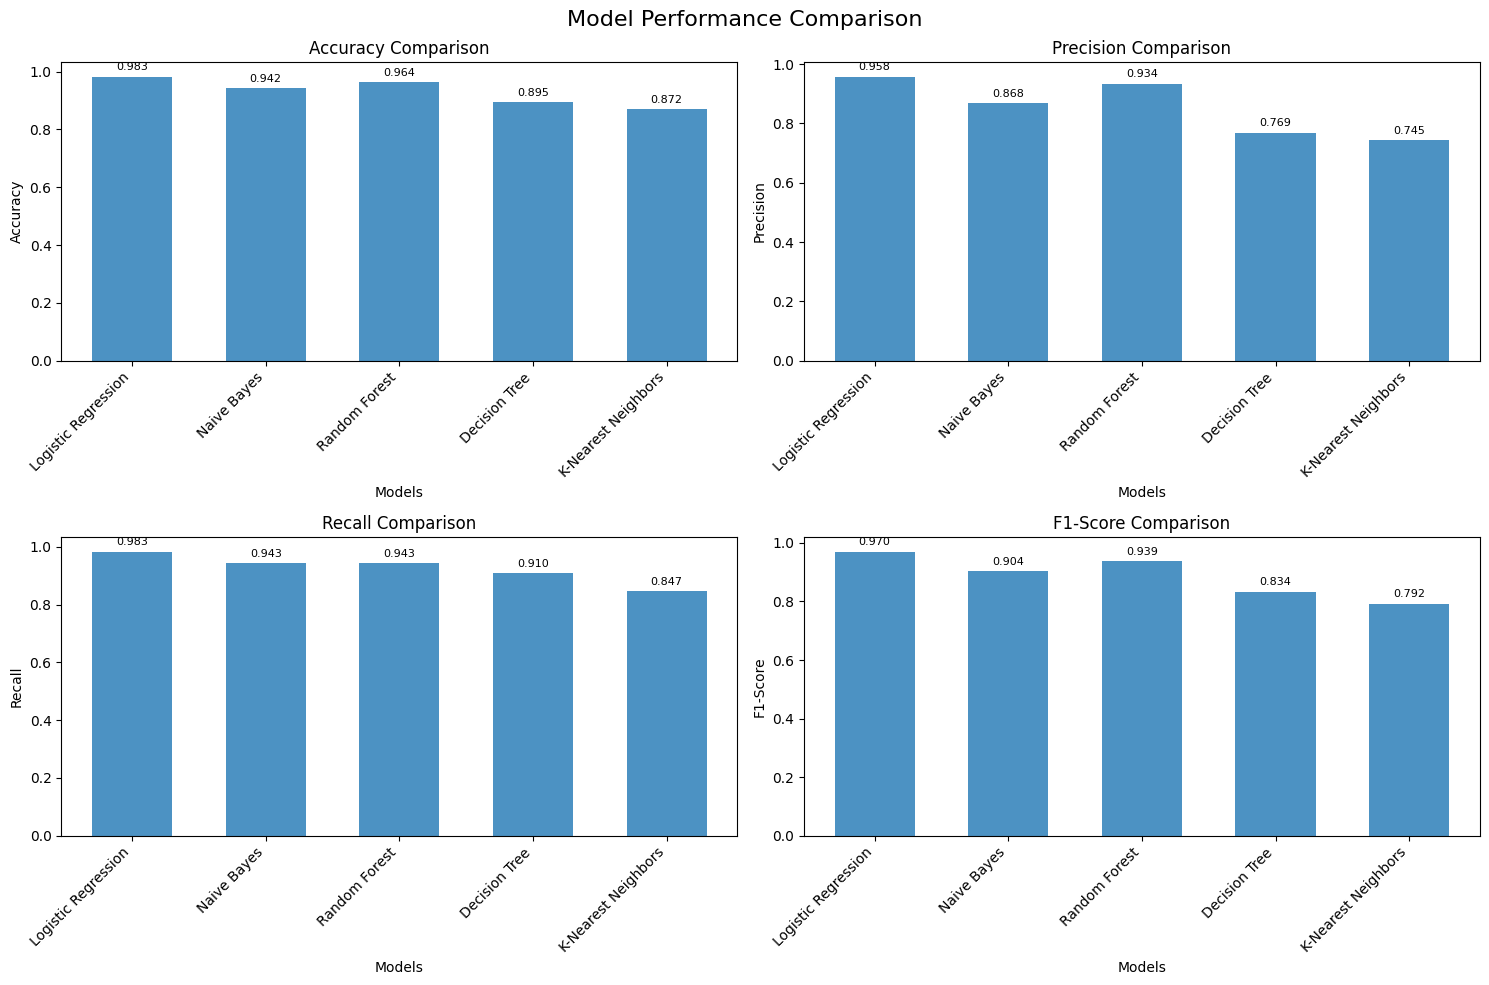

In [31]:
# Step 10: Visualize Model Performance
plt.figure(figsize=(15, 10))

# Performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.15

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Performance Comparison', fontsize=16)

for i, metric in enumerate(metrics):
    ax = axes[i//2, i%2]
    bars = ax.bar(x, results_df[metric], width=0.6, alpha=0.8)
    ax.set_xlabel('Models')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [35]:
import joblib

# Identify the best model based on Accuracy (you can change the metric if needed)
best_model_row = results_df.loc[results_df['Accuracy'].idxmax()]
best_model_name = best_model_row['Model']

print(f"The best performing model based on Accuracy is: {best_model_name}")

# Retrieve the best model object from the 'models' dictionary
best_model = models[best_model_name]

# Define the filename for saving the model
filename = f'{best_model_name.replace(" ", "_").lower()}_spam_classifier.joblib'

# Save the model to a file
joblib.dump(best_model, filename)

print(f"\nBest model saved to: {filename}")

The best performing model based on Accuracy is: Logistic Regression

Best model saved to: logistic_regression_spam_classifier.joblib


Examples of predictions on test data:

Comparing Actual and Predicted Labels for Examples:
Example 1 (Index 3456): Actual Label is 'Ham', Predicted Label is 'Ham'.
Example 2 (Index 3351): Actual Label is 'Spam', Predicted Label is 'Spam'.
Example 3 (Index 3733): Actual Label is 'Ham', Predicted Label is 'Ham'.
Example 4 (Index 5024): Actual Label is 'Ham', Predicted Label is 'Ham'.
Example 5 (Index 3090): Actual Label is 'Ham', Predicted Label is 'Ham'.

Word counts for the example predictions:


,the,to,ect,and,for,of,a,you,hou,in,...,enhancements,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry
3456,45,38,7,35,12,27,466,23,1,65,...,0,0,0,0,2,0,0,0,5,0
3351,12,13,5,7,11,6,123,8,1,25,...,0,0,0,0,0,0,0,0,4,0
3733,2,2,1,2,2,0,19,0,0,3,...,0,0,0,0,0,0,0,0,0,0
5024,28,30,4,9,8,8,129,5,0,23,...,0,0,0,0,2,0,0,0,2,0
3090,4,1,1,1,2,1,12,0,0,1,...,0,0,0,0,0,0,0,0,0,0



Visualizing Actual vs Predicted Labels for Examples:


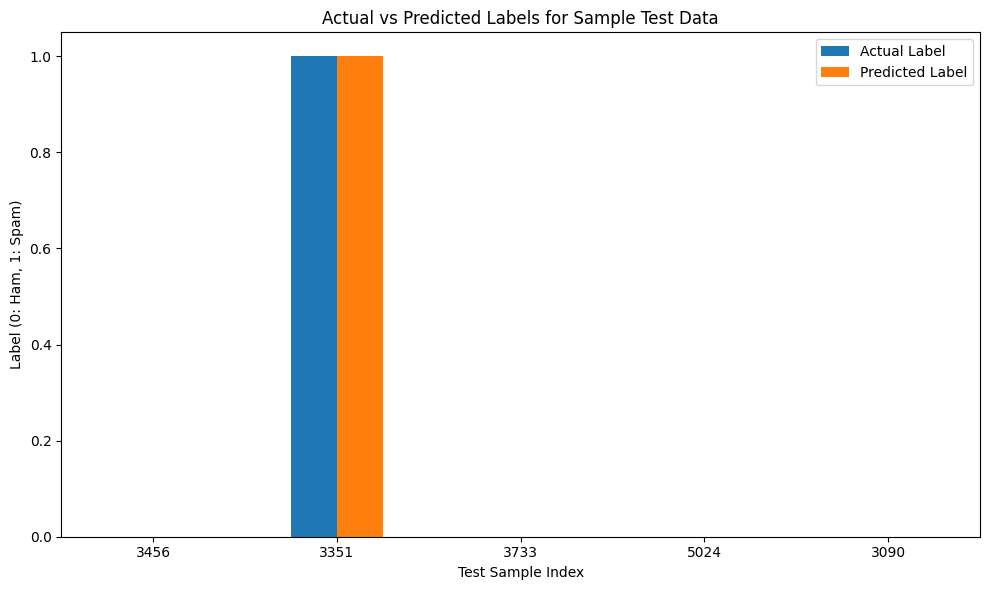

In [40]:
# Display examples of predictions on test data
print("Examples of predictions on test data:")

# Select a few examples from the test set
num_examples = 5
example_indices = X_test.sample(n=num_examples, random_state=42).index

# Get the example data, actual labels, and predictions
example_data = X_test.loc[example_indices]
actual_labels = y_test.loc[example_indices]
predicted_labels = best_model.predict(example_data)

# Display the comparison of actual vs predicted labels in sentence form
print("\nComparing Actual and Predicted Labels for Examples:")
for i, index in enumerate(example_indices):
    actual = "Spam" if actual_labels.loc[index] == 1 else "Ham"
    predicted = "Spam" if predicted_labels[i] == 1 else "Ham"
    print(f"Example {i+1} (Index {index}): Actual Label is '{actual}', Predicted Label is '{predicted}'.")

# Display the actual word counts for these examples (the features used for prediction)
print("\nWord counts for the example predictions:")
display(example_data)

# Visualize actual vs predicted labels for examples using a bar graph
print("\nVisualizing Actual vs Predicted Labels for Examples:")
predictions_df = pd.DataFrame({
    'Actual Label': actual_labels,
    'Predicted Label': predicted_labels
}, index=example_indices)
predictions_df.plot(kind='bar', figsize=(10, 6))
plt.title('Actual vs Predicted Labels for Sample Test Data')
plt.xlabel('Test Sample Index')
plt.ylabel('Label (0: Ham, 1: Spam)')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()